# Comparacion de modelos de clasificacion RF, ExtraTrees, Logistic Regression

In [ ]:
# Standard libraries
import os
import warnings

# Data manipulation and numerical computation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn utilities
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_predict
from sklearn.metrics import (
    balanced_accuracy_score, f1_score, confusion_matrix, classification_report
)
from sklearn.calibration import CalibratedClassifierCV

# Statistical distributions
from scipy.stats import loguniform, randint, uniform

# Typing utilities
from typing import Dict, Any, List, Optional, Tuple


In [2]:
sns.set(style="ticks", context="notebook", palette="deep")
pd.set_option('display.max_columns', None)
palette = {'Bad':'#b2182b','Poor':'#d6604d','Moderate':'#f1a340','Good':'#5aae61','High':'#1b7837'}

In [3]:
path = "../../data/processed/"
dfs = {}

# read 03_CLEAN_COMPLETE_DF.parquet
df1 = pd.read_parquet(os.path.join(path, "taxones_pressure_train.parquet"))
df2 = pd.read_parquet(os.path.join(path, "taxones_pressure_predict.parquet"))
df = pd.concat([df1, df2], ignore_index=True)

In [4]:
# change unassessed values to NaN
df = df.replace("Unassessed", np.nan)
df = df.replace("None", np.nan)

# index SamplingOperations_code
df = df.set_index('SamplingOperations_code')
 
# DROP HERlvl2Code	Altitude Longitude_Lambert93	Latitude_Lambert93	Watershed	CodeDepartement	HERlvl1Code
df = df.drop(columns=['HERlvl2Code', 'HERlvl2Name', 'HERlvl1Name', 'Altitude','Longitude_Lambert93','Latitude_Lambert93','Watershed','CodeDepartement', 'CodeSite_SamplingOperations', 'Date_SamplingOperation'])
df

TotalAbundance_SamplingOperation  Achaa01  Achac01  \
SamplingOperations_code                                                       
S02000008_20170703                                    405      NaN      NaN   
S02000008_20200708                                    400      NaN      NaN   
S02000010_20070906                                    400      NaN      NaN   
S02000010_20090721                                    400      NaN      NaN   
S02000010_20110723                                    398      NaN      NaN   
...                                                   ...      ...      ...   
S06940940_20100708                                    438      NaN      NaN   
S06940940_20230623                                    408      NaN      NaN   
S06960950_20160629                                    401      NaN      NaN   
S06960950_20180719                                    416      NaN      NaN   
S06970900_20150601                                    432      NaN      NaN   

                         Achaf01    Achaf02  Achal01  Acham01  Achan01  \
SamplingOperations_code                                                  
S02000008_20170703           NaN        NaN      NaN      NaN      NaN   
S02000008_20200708           NaN        NaN      NaN      NaN      NaN   
S02000010_20070906           NaN        NaN      NaN      NaN      NaN   
S02000010_20090721           NaN        NaN      NaN      NaN      NaN   
S02000010_20110723           NaN        NaN      NaN      NaN      NaN   
...                          ...        ...      ...      ...      ...   
S06940940_20100708           NaN        NaN      NaN      NaN      NaN   
S06940940_20230623           NaN        NaN      NaN      NaN      NaN   
S06960950_20160629           NaN        NaN      NaN      NaN      NaN   
S06960950_20180719           NaN  19.230769      NaN      NaN      NaN   
S06970900_20150601           NaN        NaN      NaN      NaN      NaN   

                         Achat01   Achat02  Achat03  Achba01  Achbi01  \
SamplingOperations_code                                                 
S02000008_20170703           NaN       NaN      NaN      NaN      NaN   
S02000008_20200708           NaN       NaN      NaN      NaN      NaN   
S02000010_20070906           NaN       NaN      NaN      NaN      NaN   
S02000010_20090721           NaN       NaN      NaN      NaN      NaN   
S02000010_20110723           NaN       NaN      NaN      NaN      NaN   
...                          ...       ...      ...      ...      ...   
S06940940_20100708           NaN       NaN      NaN      NaN      NaN   
S06940940_20230623           NaN       NaN      NaN      NaN      NaN   
S06960950_20160629           NaN       NaN      NaN      NaN      NaN   
S06960950_20180719           NaN       NaN      NaN      NaN      NaN   
S06970900_20150601           NaN  6.944444      NaN      NaN      NaN   

                         Achbi02   Achbr01  Achca01  Achca02  Achca03  \
SamplingOperations_code                                                 
S02000008_20170703           NaN       NaN      NaN      NaN      NaN   
S02000008_20200708           NaN       NaN      NaN      NaN      NaN   
S02000010_20070906           NaN       NaN      NaN      NaN      NaN   
S02000010_20090721           NaN       NaN      NaN      NaN      NaN   
S02000010_20110723           NaN       NaN      NaN      NaN      NaN   
...                          ...       ...      ...      ...      ...   
S06940940_20100708           NaN  2.283105      NaN      NaN      NaN   
S06940940_20230623           NaN       NaN      NaN      NaN      NaN   
S06960950_20160629           NaN       NaN      NaN      NaN      NaN   
S06960950_20180719           NaN       NaN      NaN      NaN      NaN   
S06970900_20150601           NaN       NaN      NaN      NaN      NaN   

                         Achca04  Achch01  Achcl01  Achco01  Achco02  Achco03  \
SamplingOperations_code                              

# For each region

In [5]:
import cleandf

In [6]:
# For all regions 1, 2, ..., 22
regiondfs = {}
for region in range(1, 2):
    print(f"Region: {region}")
    regiondf = df[df['HERlvl1Code'] == region]

    cleanregion = cleandf.IWANTMYXCLEAN(regiondf, thresh_high_missing=.99)
    regiondfs[region] = cleanregion

Region: 1
Dropped exact duplicate columns: ['Achac01', 'Achal01', 'Achca01', 'Achch01', 'Achcl01', 'Achco01', 'Achco03', 'Achcy01', 'Achde01', 'Achde02', 'Achdi01', 'Achdi02', 'Achel01', 'Achen01', 'Achex03', 'Achfl01', 'Achfr01', 'Achgr01', 'Achgr02', 'Achha01', 'Achhe01', 'Achhi01', 'Achho01', 'Achho02', 'Achim01', 'Achim02', 'Achim03', 'Achin01', 'Achin02', 'Achjo01', 'Achko01', 'Achkr01', 'Achkr03', 'Achkr04', 'Achku01', 'Achla01', 'Achla05', 'Achle01', 'Achle02', 'Achli02', 'Achli04', 'Achlo01', 'Achlu01', 'Achlu02', 'Achmo01', 'Achmo02', 'Achna01', 'Achna02', 'Achni01', 'Achno01', 'Achpa01', 'Achpe01', 'Achpe02', 'Achpl01', 'Achpo01', 'Achpr01', 'Achpr02', 'Achps01', 'Achps02', 'Achps03', 'Achpu01', 'Achro01', 'Achro03', 'Achru02', 'Achsc01', 'Achse01', 'Achse02', 'Achsi01', 'Achst01', 'Achst02', 'Achst04', 'Achsu02', 'Achsu04', 'Achtu01', 'Achzi01', 'Actde01', 'Actno01', 'Actro01', 'Actse01', 'Actsp01', 'Actsu01', 'Actvu01', 'Adlaq01', 'Adlbr01', 'Adlmu01', 'Adlmu02', 'Adlpa01',

In [7]:
regiondfs[1]

,TotalAbundance_SamplingOperation,Achaf02,Achat02,Achca02,Achca04,Achco02,Achco04,Achcr01,Achda01,Achde03,Achdr01,Acheu01,Achex02,Achho03,Achla02,Achla04,Achla06,Achli03,Achmi02,Achob01,Achpy01,Achri01,Achro04,Achst03,Achsu01,Achsu03,Achth01,Achzh01,Adlbr02,Adlmi01,Adlsu01,Ampin01,Ampin02,Amppe01,Amppe02,Aulam01,Calae01,Calba01,Cocdi01,Coceu01,Cocli01,Cocne02,Cocpa01,Cocpe01,Cocpl01,Cycme02,Cycps01,Cymaf02,Cymco01,Cymex01,Cymex02,Cymmi01,Cymre01,Cymsi01,Cymve01,Delde02,Dente01,Diaeh01,Diame01,Diavu01,Didge01,Dipse01,Encmi03,Encmi04,Encsi02,Encsu03,Encvu01,Eucla01,Exiva01,Fraau01,Fraca04,Fragr01,Frami03,Frane04,Frapa01,Frape01,Frare01,Fraru01,Frate01,Frave01,Fruco01,Geiac01,Goman05,Gomca01,Gomca02,Gomcu02,Gomcy01,Gomel01,Gomex01,Gomin06,Gommi01,Gommi02,Gommi03,Gommi05,Gomol03,Gomol04,Gompa06,Gompu02,Gomrh01,Gomte02,Hanar01,Himmi01,Karcl01,Melva01,Merci01,Micgr01,Navan05,Navar02,Navca07,Navca08,Navca10,Navca11,Navcr05,Navcr09,Navcr10,Navde03,Navex02,Navgr01,Navla04,Navle02,Navmi09,Navmo05,Navoc01,Navpe05,Navpe06,Navra01,Navre04,Navsa03,Navsp02,Navsu03,Navsu07,Navsu08,Navve03,Nitac05,Nitam01,Nitar01,Nitco07,Nitde03,Nitdi04,Nitfo01,Nitin02,Nitla03,Nitli03,Nitme01,Nitpa01,Nitpa02,Nitre01,Nitso01,Nitso04,Nitsu05,Nupla01,Panco02,Plala02,Plesc01,Psabi01,Punra01,Reisi01,Reiun01,Rhoab01,Selat01,Selni01,Selsa02,Suran01,Surla01,Synde01,Synul01,Vibtr01,Streamsize,Nitrogencompounds_Status1Y,Nitrogencompounds_Status180D,Nitrogencompounds_Status90D,Nitrates_Status1Y,Nitrates_Status180D,Nitrates_Status90D,Phosphorouscompounds_Status1Y,Phosphorouscompounds_Status180D,Phosphorouscompounds_Status90D,Acidification_Status1Y,Acidification_Status180D,Acidification_Status90D,PAH_Status1Y,PAH_Status180D,PAH_Status90D,OrganicMatter_Status1Y,OrganicMatter_Status180D,OrganicMatter_Status90D,SuspendedMatter_Status1Y,SuspendedMatter_Status180D,SuspendedMatter_Status90D,OrganicMicropollutants_Status1Y,OrganicMicropollutants_Status180D,OrganicMicropollutants_Status90D,MineralMicropollutants_Status1Y,MineralMicropollutants_Status180D,MineralMicropollutants_Status90D,IBD,IBD_EQR,IBD_EQR_Status,Uncommon_Taxons,QuasiConstant_Numeric
SamplingOperations_code,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
S05168100_20070809,400,NaN,45.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,80.000000,NaN,682.500000,NaN,NaN,NaN,50.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.000000,70.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,27.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.5,NaN,NaN,NaN,NaN,NaN,NaN,7.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.5,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TP,High,High,High,High,High,High,High,High,High,High,High,High,NaN,NaN,NaN,Bad,Bad,Bad,High,High,High,High,High,High,NaN,NaN,NaN,20.0,1.0,High,0.000000,1
S05168100_20080806,400,NaN,60.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.000000,NaN,765.000000,15.0,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.500000,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.000000,NaN,2.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.50000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,2.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,20.000000,NaN,NaN,NaN,2.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,Na

In [ ]:
def _resolve_col_case(df: pd.DataFrame, name: str) -> str:
    if name in df.columns:
        return name
    low = name.lower()
    for c in df.columns:
        if c.lower() == low:
            return c
    raise KeyError(f"Column '{name}' not found (case-insensitive).")

def _build_preprocessor(X: pd.DataFrame) -> Tuple[ColumnTransformer, List[str], List[str]]:
    num_cols = X.select_dtypes(include=["number"]).columns.tolist()
    cat_cols = [c for c in X.columns if c not in num_cols]
    pre = ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imp", SimpleImputer(strategy="median"))]), num_cols),
            ("cat", Pipeline([
                ("imp", SimpleImputer(strategy="constant", fill_value="None")),
                ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
            ]), cat_cols),
        ],
        remainder="drop",
    )
    return pre, num_cols, cat_cols

def _feature_names_from_pre(pre: ColumnTransformer, num_cols: List[str], cat_cols: List[str]) -> List[str]:
    names: List[str] = []
    if num_cols:
        names.extend(num_cols)
    if cat_cols and "cat" in pre.named_transformers_:
        ohe = pre.named_transformers_["cat"].named_steps["ohe"]
        names.extend(ohe.get_feature_names_out(cat_cols).tolist())
    return names

def _cv_for(y: pd.Series, max_splits: int = 5) -> StratifiedKFold:
    counts = y.value_counts(dropna=False)
    min_class = int(counts.min())
    n_splits = max(2, min(max_splits, min_class))  # at least 2, but not exceeding smallest class
    return StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

def _can_kfold(y: pd.Series, cv: Optional[StratifiedKFold]) -> bool:
    if cv is None:
        return False
    n_folds = cv.get_n_splits()
    return int(y.value_counts().min()) >= n_folds


# ---------------- main class ----------------

class MultiRegionAutoClassifier:
    """
    One best model per region for a categorical target (e.g., 'IBD_EQR_Status').
    Trains on all non-NaN labels, predicts missing labels, stores OOF diagnostics and probabilities.
    """

    def __init__(self, xcleans: Dict[Any, pd.DataFrame], random_state: int = 42, verbose: bool = True):
        self.xcleans = xcleans
        self.random_state = random_state
        self.verbose = verbose
        self.results: Dict[Any, Dict[str, Any]] = {}
        self.target_column: Optional[str] = None

    # ---- candidate model spaces ----
    def _candidate_spaces(self) -> Dict[str, Tuple[Any, dict]]:
        rng = self.random_state
        # ExtraTrees
        et = ExtraTreesClassifier(random_state=rng, class_weight="balanced")
        et_grid = {
            "model__n_estimators": randint(300, 1001),
            "model__max_depth": [None] + list(range(6, 21)),
            "model__min_samples_leaf": randint(1, 6),
            "model__min_samples_split": randint(2, 9),
            "model__max_features": ["sqrt", None, 0.2, 0.5, 0.8],
            "model__bootstrap": [False, True],
        }
        # RandomForest
        rf = RandomForestClassifier(random_state=rng, class_weight="balanced", n_jobs=-1)
        rf_grid = {
            "model__n_estimators": randint(300, 1001),
            "model__max_depth": [None] + list(range(6, 21)),
            "model__min_samples_leaf": randint(1, 6),
            "model__min_samples_split": randint(2, 9),
            "model__max_features": ["sqrt", None, 0.2, 0.5, 0.8],
            "model__bootstrap": [True],
        }
        # LogisticRegression (saga, elastic-net)
        lr = LogisticRegression(
            solver="saga", penalty="elasticnet", class_weight="balanced",
            max_iter=5000, random_state=rng, n_jobs=None
        )
        lr_grid = {
            "model__C": loguniform(1e-3, 1e2),
            "model__l1_ratio": uniform(0.0, 1.0),
        }
        return {
            "ExtraTrees": (et, et_grid),
            "RandomForest": (rf, rf_grid),
            "LogRegEN": (lr, lr_grid),
        }

    # ---- core routine ----
    def process_missing_class(
        self,
        target_column: str = "IBD_EQR_Status",
        max_splits: int = 5,
        n_iter_per_model: int = 25,
        scoring: str = "balanced_accuracy",
        calibrate: bool = True,
        prob_method: str = "predict_proba",
    ):
        self.results.clear()
        self.target_column = target_column

        for key, Xclean in self.xcleans.items():
            try:
                y_col = _resolve_col_case(Xclean, target_column)
            except KeyError:
                if self.verbose: print(f"[skip {key}] missing target '{target_column}'")
                continue
            if len(Xclean) < 5:
                if self.verbose: print(f"[skip {key}] too few rows: {len(Xclean)}")
                continue

            y = Xclean[y_col]
            leak = {y_col, "IBD", "IBD_EQR", "IBD_EQR_Status", "IBD_EQR_STATUS"}
            X = Xclean.drop(columns=[c for c in leak if c in Xclean.columns], errors="ignore")

            mask_tr = y.notna()
            mask_te = ~mask_tr
            if mask_tr.sum() == 0:
                if self.verbose: print(f"[skip {key}] no labeled rows")
                continue

            pre, num_cols, cat_cols = _build_preprocessor(X)
            cv = _cv_for(y.loc[mask_tr], max_splits=max_splits)

            # search over candidates
            best = {"name": None, "estimator": None, "cv_score": -np.inf, "cv_results_": None}
            for name, (estimator, grid) in self._candidate_spaces().items():
                pipe = Pipeline([("pre", pre), ("model", estimator)])
                search = RandomizedSearchCV(
                    estimator=pipe,
                    param_distributions=grid,
                    n_iter=n_iter_per_model,
                    scoring=scoring,
                    cv=cv,
                    refit=True,
                    n_jobs=-1,
                    verbose=0,
                    random_state=self.random_state,
                )
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    search.fit(X.loc[mask_tr], y.loc[mask_tr])

                mean_score = float(np.max(search.cv_results_["mean_test_score"]))
                if self.verbose:
                    print(f"[{key}] {name}: best {scoring}={mean_score:.3f}")
                if mean_score > best["cv_score"]:
                    best.update({"name": name, "estimator": search.best_estimator_, "cv_score": mean_score,
                                 "cv_results_": search.cv_results_})

            if best["estimator"] is None:
                if self.verbose: print(f"[skip {key}] no model selected")
                continue

            best_pipe: Pipeline = best["estimator"]

            # ---- OOF diagnostics on labeled rows (guarded) ----
            y_tr = y.loc[mask_tr]
            if _can_kfold(y_tr, cv):
                try:
                    oof_pred = cross_val_predict(best_pipe, X.loc[mask_tr], y_tr, cv=cv, method="predict", n_jobs=-1)
                except Exception:
                    oof_pred = cross_val_predict(best_pipe, X.loc[mask_tr], y_tr, cv=cv, method=None, n_jobs=-1)
                oof_bal_acc = balanced_accuracy_score(y_tr, oof_pred)
                oof_f1_macro = f1_score(y_tr, oof_pred, average="macro")
                cm = confusion_matrix(y_tr, oof_pred, labels=np.unique(y_tr))
            else:
                if self.verbose:
                    print(f"[{key}] skip OOF: min_class={int(y_tr.value_counts().min())} < folds={cv.get_n_splits()}")
                best_pipe.fit(X.loc[mask_tr], y_tr)
                oof_pred = best_pipe.predict(X.loc[mask_tr])
                oof_bal_acc = balanced_accuracy_score(y_tr, oof_pred)
                oof_f1_macro = f1_score(y_tr, oof_pred, average="macro")
                cm = confusion_matrix(y_tr, oof_pred, labels=np.unique(y_tr))

            cm_df = pd.DataFrame(cm, index=[f"true_{c}" for c in np.unique(y_tr)],
                                 columns=[f"pred_{c}" for c in np.unique(y_tr)])

            # ---- Refit on all labeled rows ----
            best_pipe.fit(X.loc[mask_tr], y_tr)

            # ---- Probability calibration (guarded) ----
            calibrated_pipe = best_pipe
            if calibrate and _can_kfold(y_tr, cv):
                base = best_pipe
                final_est = base.named_steps["model"]
                if hasattr(final_est, "predict_proba") or hasattr(final_est, "decision_function"):
                    calib = CalibratedClassifierCV(final_est, cv=cv, method="isotonic")
                    calibrated_pipe = Pipeline([("pre", base.named_steps["pre"]), ("model", calib)])
                    calibrated_pipe.fit(X.loc[mask_tr], y_tr)
            else:
                if calibrate and self.verbose:
                    print(f"[{key}] skip calibration: min_class={int(y_tr.value_counts().min())} < folds={cv.get_n_splits()}")

            # ---- Predict missing rows ----
            if mask_te.any():
                X_te = X.loc[mask_te]
                yhat_te = pd.Series(calibrated_pipe.predict(X_te), index=X_te.index, name="yhat_te")
                # probabilities
                if hasattr(calibrated_pipe, "predict_proba"):
                    proba = calibrated_pipe.predict_proba(X_te)
                    classes = calibrated_pipe.named_steps["model"].classes_
                    proba_te = pd.DataFrame(proba, index=X_te.index, columns=[f"proba_{c}" for c in classes])
                elif hasattr(calibrated_pipe, "decision_function"):
                    dec = calibrated_pipe.decision_function(X_te)
                    dec = np.atleast_2d(dec)
                    if dec.ndim == 1:
                        dec = np.c_[-dec, dec]
                    e = np.exp(dec - dec.max(axis=1, keepdims=True))
                    soft = e / e.sum(axis=1, keepdims=True)
                    classes = np.unique(y_tr)
                    proba_te = pd.DataFrame(soft, index=X_te.index, columns=[f"proba_{c}" for c in classes])
                else:
                    proba_te = pd.DataFrame(index=X_te.index)
            else:
                yhat_te = pd.Series(dtype=object, name="yhat_te")
                proba_te = pd.DataFrame()

            # ---- Feature importances (if available) ----
            final_est = best_pipe.named_steps["model"]
            pre_fitted = best_pipe.named_steps["pre"]
            # reuse num_cols, cat_cols computed earlier
            feat_names = _feature_names_from_pre(pre_fitted, num_cols, cat_cols)
            if hasattr(final_est, "feature_importances_"):
                fi = pd.Series(final_est.feature_importances_, index=feat_names).sort_values(ascending=False)
            else:
                fi = pd.Series(dtype=float)

            # ---- Filled target ----
            y_filled = y.copy()
            if mask_te.any():
                y_filled.loc[mask_te] = yhat_te.values

            # ---- Store ----
            self.results[key] = {
                "best_name": best["name"],
                "best_cv_score_bal_acc": best["cv_score"],
                "oof_bal_acc": oof_bal_acc,
                "oof_f1_macro": oof_f1_macro,
                "oof_confusion": cm_df,
                "classes_": np.unique(y_tr),
                "model": calibrated_pipe,
                "uncalibrated_model": best_pipe,
                "n_train": int(mask_tr.sum()),
                "n_infer": int(mask_te.sum()),
                "y_tr": y_tr,
                "oof_pred": pd.Series(oof_pred, index=y_tr.index, name="oof_pred"),
                "yhat_te": yhat_te,
                "proba_te": proba_te,
                "y_filled": y_filled,
                "feature_importances": fi,
            }

            if self.verbose:
                print(f"[done {key}] best={best['name']}  OOF_bal_acc={oof_bal_acc:.3f}  "
                      f"OOF_f1_macro={oof_f1_macro:.3f}  infer={int(mask_te.sum())}")

    # ------------- convenience APIs -------------

    def infer_table(self, key: Any) -> pd.DataFrame:
        r = self.results[key]
        idx = self.xcleans[key].index
        out = pd.DataFrame(index=idx)
        out["y_true"] = r["y_tr"]
        out["oof_pred"] = r["oof_pred"]
        out["yhat_te"] = r["yhat_te"]
        out["y_filled"] = r["y_filled"]
        out = out.join(r["proba_te"], how="left")
        return out

    def all_inferred(self) -> pd.DataFrame:
        frames = []
        for k in self.results:
            df = self.infer_table(k).reset_index().rename(columns={"index": "row_id"})
            df.insert(0, "region", k)
            frames.append(df)
        return pd.concat(frames, ignore_index=True)

    def filled_dataframe(self, key: Any) -> pd.DataFrame:
        if self.target_column is None:
            raise RuntimeError("Run process_missing_class first.")
        df = self.xcleans[key].copy()
        col = _resolve_col_case(df, self.target_column)
        df[col] = self.results[key]["y_filled"]
        return df

    def top_features(self, key: Any, k: int = 20) -> pd.DataFrame:
        fi = self.results[key]["feature_importances"]
        if fi.empty:
            raise ValueError("Feature importances unavailable for the selected model.")
        return fi.head(k).reset_index().rename(columns={"index": "feature", 0: "importance"})

    def print_report(self, key: Any):
        r = self.results[key]
        y_tr = r["y_tr"]
        y_pred = r["oof_pred"].reindex(y_tr.index)
        print(classification_report(y_tr, y_pred, digits=3))
        print("OOF confusion matrix:")
        print(r["oof_confusion"])

    def plot_oof_confusion(self, key: Any):
        cm = self.results[key]["oof_confusion"]
        plt.figure(figsize=(5, 4))
        plt.imshow(cm.values, interpolation="nearest")
        plt.xticks(range(len(cm.columns)), cm.columns, rotation=45, ha="right")
        plt.yticks(range(len(cm.index)), cm.index)
        plt.title(f"OOF confusion — region {key}")
        plt.colorbar()
        plt.tight_layout()
        plt.show()

    def predict_new(self, key: Any, X_new: pd.DataFrame) -> np.ndarray:
        return self.results[key]["model"].predict(X_new)

    def predict_proba_new(self, key: Any, X_new: pd.DataFrame) -> np.ndarray:
        mdl = self.results[key]["model"]
        if hasattr(mdl, "predict_proba"):
            return mdl.predict_proba(X_new)
        raise AttributeError("Model does not support predict_proba.")


In [30]:
auto = MultiRegionAutoClassifier(regiondfs, random_state=42, verbose=True)

In [33]:
auto = MultiRegionAutoClassifier(regiondfs, random_state=42, verbose=True)
auto.process_missing_class(target_column="IBD_EQR_STATUS", max_splits=5, n_iter_per_model=2, calibrate=True)

[1] ExtraTrees: best balanced_accuracy=0.463
[1] RandomForest: best balanced_accuracy=0.502
[1] LogRegEN: best balanced_accuracy=0.583
[1] skip OOF: min_class=1 < folds=2
[1] skip calibration: min_class=1 < folds=2
[done 1] best=LogRegEN  OOF_bal_acc=0.960  OOF_f1_macro=0.928  infer=172


In [35]:
tbl = auto.infer_table(1)
tbl

,y_true,oof_pred,yhat_te,y_filled,proba_Bad,proba_Good,proba_High,proba_Moderate,proba_Poor
SamplingOperations_code,,,,,,,,,
S05168100_20070809,High,High,NaN,High,NaN,NaN,NaN,NaN,NaN
S05168100_20080806,High,High,NaN,High,NaN,NaN,NaN,NaN,NaN
S05168100_20090625,High,High,NaN,High,NaN,NaN,NaN,NaN,NaN
S05168100_20100629,High,High,NaN,High,NaN,NaN,NaN,NaN,NaN
S05168100_20110809,High,High,NaN,High,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
S06175540_20150728,NaN,NaN,High,High,6.671863e-103,0.010203,0.989796,0.000001,1.888236e-49
S06175600_20170904,NaN,NaN,High,High,4.048135e-88,0.158513,0.841380,0.000107,5.508117e-20
S06175600_20180926,NaN,NaN,High,High,5.791972e-72,0.328398,0.666903,0.004699,8.021134e-25


In [37]:
df_filled = auto.filled_dataframe(1)
df_filled

,TotalAbundance_SamplingOperation,Achaf02,Achat02,Achca02,Achca04,Achco02,Achco04,Achcr01,Achda01,Achde03,Achdr01,Acheu01,Achex02,Achho03,Achla02,Achla04,Achla06,Achli03,Achmi02,Achob01,Achpy01,Achri01,Achro04,Achst03,Achsu01,Achsu03,Achth01,Achzh01,Adlbr02,Adlmi01,Adlsu01,Ampin01,Ampin02,Amppe01,Amppe02,Aulam01,Calae01,Calba01,Cocdi01,Coceu01,Cocli01,Cocne02,Cocpa01,Cocpe01,Cocpl01,Cycme02,Cycps01,Cymaf02,Cymco01,Cymex01,Cymex02,Cymmi01,Cymre01,Cymsi01,Cymve01,Delde02,Dente01,Diaeh01,Diame01,Diavu01,Didge01,Dipse01,Encmi03,Encmi04,Encsi02,Encsu03,Encvu01,Eucla01,Exiva01,Fraau01,Fraca04,Fragr01,Frami03,Frane04,Frapa01,Frape01,Frare01,Fraru01,Frate01,Frave01,Fruco01,Geiac01,Goman05,Gomca01,Gomca02,Gomcu02,Gomcy01,Gomel01,Gomex01,Gomin06,Gommi01,Gommi02,Gommi03,Gommi05,Gomol03,Gomol04,Gompa06,Gompu02,Gomrh01,Gomte02,Hanar01,Himmi01,Karcl01,Melva01,Merci01,Micgr01,Navan05,Navar02,Navca07,Navca08,Navca10,Navca11,Navcr05,Navcr09,Navcr10,Navde03,Navex02,Navgr01,Navla04,Navle02,Navmi09,Navmo05,Navoc01,Navpe05,Navpe06,Navra01,Navre04,Navsa03,Navsp02,Navsu03,Navsu07,Navsu08,Navve03,Nitac05,Nitam01,Nitar01,Nitco07,Nitde03,Nitdi04,Nitfo01,Nitin02,Nitla03,Nitli03,Nitme01,Nitpa01,Nitpa02,Nitre01,Nitso01,Nitso04,Nitsu05,Nupla01,Panco02,Plala02,Plesc01,Psabi01,Punra01,Reisi01,Reiun01,Rhoab01,Selat01,Selni01,Selsa02,Suran01,Surla01,Synde01,Synul01,Vibtr01,Streamsize,Nitrogencompounds_Status1Y,Nitrogencompounds_Status180D,Nitrogencompounds_Status90D,Nitrates_Status1Y,Nitrates_Status180D,Nitrates_Status90D,Phosphorouscompounds_Status1Y,Phosphorouscompounds_Status180D,Phosphorouscompounds_Status90D,Acidification_Status1Y,Acidification_Status180D,Acidification_Status90D,PAH_Status1Y,PAH_Status180D,PAH_Status90D,OrganicMatter_Status1Y,OrganicMatter_Status180D,OrganicMatter_Status90D,SuspendedMatter_Status1Y,SuspendedMatter_Status180D,SuspendedMatter_Status90D,OrganicMicropollutants_Status1Y,OrganicMicropollutants_Status180D,OrganicMicropollutants_Status90D,MineralMicropollutants_Status1Y,MineralMicropollutants_Status180D,MineralMicropollutants_Status90D,IBD,IBD_EQR,IBD_EQR_Status,Uncommon_Taxons,QuasiConstant_Numeric
SamplingOperations_code,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
S05168100_20070809,400,NaN,45.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,80.000000,NaN,682.500000,NaN,NaN,NaN,50.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.000000,70.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,27.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.5,NaN,NaN,NaN,NaN,NaN,NaN,7.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.5,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TP,High,High,High,High,High,High,High,High,High,High,High,High,NaN,NaN,NaN,Bad,Bad,Bad,High,High,High,High,High,High,NaN,NaN,NaN,20.0,1.0,High,0.000000,1
S05168100_20080806,400,NaN,60.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.000000,NaN,765.000000,15.0,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.500000,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.000000,NaN,2.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.50000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,2.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,20.000000,NaN,NaN,NaN,2.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,Na

In [38]:
all_preds = auto.all_inferred()
all_preds

,region,SamplingOperations_code,y_true,oof_pred,yhat_te,y_filled,proba_Bad,proba_Good,proba_High,proba_Moderate,proba_Poor
0,1,S05168100_20070809,High,High,NaN,High,NaN,NaN,NaN,NaN,NaN
1,1,S05168100_20080806,High,High,NaN,High,NaN,NaN,NaN,NaN,NaN
2,1,S05168100_20090625,High,High,NaN,High,NaN,NaN,NaN,NaN,NaN
3,1,S05168100_20100629,High,High,NaN,High,NaN,NaN,NaN,NaN,NaN
4,1,S05168100_20110809,High,High,NaN,High,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
1480,1,S06175540_20150728,NaN,NaN,High,High,6.671863e-103,0.010203,0.989796,0.000001,1.888236e-49
1481,1,S06175600_20170904,NaN,NaN,High,High,4.048135e-88,0.158513,0.841380,0.000107,5.508117e-20
1482,1,S06175600_20180926,NaN,NaN,High,High,5.791972e-72,0.328398,0.666903,0.004699,8.021134e-25
1483,1,S06175645_20220809,NaN,NaN,High,High,1.022151e-97,0.032846,0.966571,0.000583,6.975961e-26


In [39]:
auto.print_report(1)

              precision    recall  f1-score   support

         Bad      1.000     1.000     1.000         1
        Good      0.744     0.901     0.815       232
        High      0.996     0.924     0.959       988
    Moderate      0.778     0.977     0.866        86
        Poor      1.000     1.000     1.000         6

    accuracy                          0.924      1313
   macro avg      0.903     0.960     0.928      1313
weighted avg      0.937     0.924     0.927      1313

OOF confusion matrix:
               pred_Bad  pred_Good  pred_High  pred_Moderate  pred_Poor
true_Bad              1          0          0              0          0
true_Good             0        209          3             20          0
true_High             0         71        913              4          0
true_Moderate         0          1          1             84          0
true_Poor             0          0          0              0          6


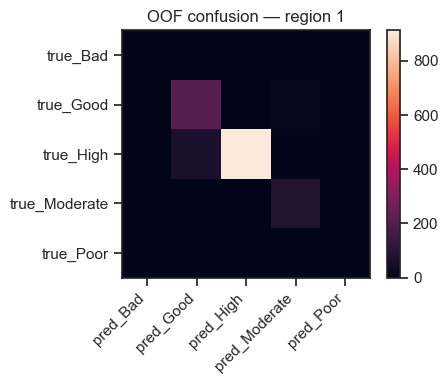

In [40]:
auto.plot_oof_confusion(1)

In [41]:
auto.results[1]["best_name"], auto.results[1]["oof_bal_acc"]

('LogRegEN', 0.960339064767588)

# Get predictions

In [42]:
all_cls = all_preds.set_index('SamplingOperations_code')
yhat_te = all_cls['yhat_te'][all_cls['yhat_te'].notna()]
yhat_te = yhat_te.to_frame()
yhat_te.to_csv('IBD_EQR_Status_predictions_5663.csv')
yhat_te

,yhat_te
SamplingOperations_code,
S05169000_20130911,High
S05169000_20200819,High
S05172000_20210813,Moderate
S05172050_20210824,Moderate
S05172350_20120827,High
...,...
S06175540_20150728,High
S06175600_20170904,High
S06175600_20180926,High
